In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

fileName = "./data/ModelsResults.xlsx"  # If it's in the current directory
sheetName = "staticOriginalResults"
df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", "BLEU"])
df

,Model,Compression,BLEU
0,pythia-70M,Original,42.000000
1,pythia-70M,8-bit,41.390000
2,pythia-70M,4-bit,39.210000
3,pythia-160M,Original,42.490000
4,pythia-160M,8-bit,42.310000
5,pythia-160M,4-bit,40.600000
6,pythia-410M,Original,43.510000
7,pythia-410M,8-bit,43.610000
8,pythia-410M,4-bit,42.410000
9,pythia-1B,Original,44.180000


# RQ-4: Generalizibility check

## preli: precision vs task performance

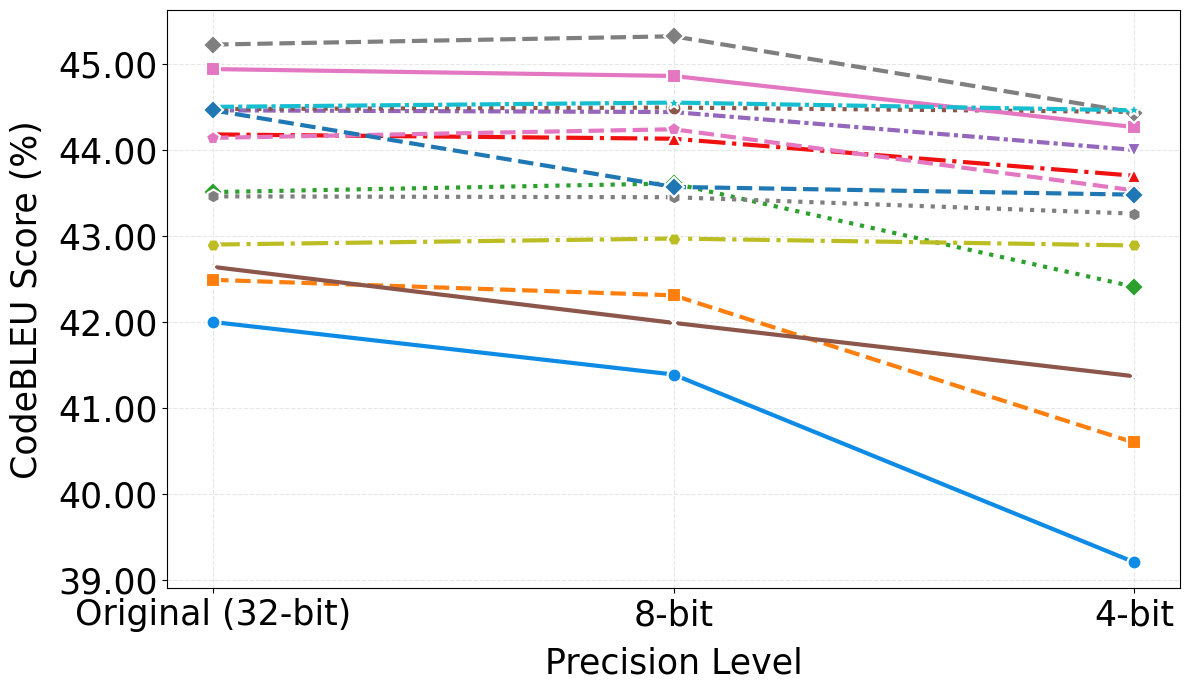

In [8]:

model_styles = {
        "pythia-70M": {"color": "#0d8be5", "marker": "o", "linestyle": "-", "dash": None, "label": "P-70M"}, #blue
        "pythia-160M": {"color": "#ff7f0e", "marker": "s", "linestyle": "--", "dash": (5, 5), "label": "P-160M"}, #orange
        "pythia-410M": {"color": "#2ca02c", "marker": "D", "linestyle": ":", "dash": (1, 1), "label": "P-410M"}, #green
        "pythia-1B": {"color": "#ef1010", "marker": "^", "linestyle": "-.", "dash": (3, 5, 1, 5), "label": "P-1B"}, #red
        "pythia-1.4B": {"color": "#9467bd", "marker": "v", "linestyle": (0, (3, 1, 1, 1)), "dash": None, "label": "P-1.4B"}, #purple
        "pythia-2.8B": {"color": "#8c564b", "marker": "o", "linestyle": ":", "dash": None, "label": "P-2.8B"}, #brown
        "pythia-6.9B": {"color": "#e377c2", "marker": "s", "linestyle": "-", "dash": (5, 2), "label": "P-6.9B"}, #olive
        "pythia-12B": {"color": "#7f7f7f", "marker": "D", "linestyle": "--", "dash": (1, 2), "label": "P-12B"}, #pink
        "gptneo-125M": {"color": "#8c564b", "marker": "x", "linestyle": "-", "dash": None, "label": "GPT-125M"}, #brown
        "gptneo-1.3B": {"color": "#e377c2", "marker": "p", "linestyle": "--", "dash": (5, 2), "label": "GPT-1.3B"}, #olive
        "codegen-350M-nl": {"color": "#7f7f7f", "marker": "h", "linestyle": ":", "dash": (1, 2), "label": "CG-350M-NL"}, #pink
        "codegen-350M-multi": {"color": "#bcbd22", "marker": "H", "linestyle": "-.", "dash": (3, 1, 1, 1), "label": "CG-350M-Multi"}, #gray
        "codegen-2B-nl": {"color": "#17becf", "marker": "*", "linestyle": (0, (5, 1, 1, 1)), "dash": None, "label": "CG-2B-NL"}, #teal
        "codegen-2B-multi": {"color": "#1f77b4", "marker": "D", "linestyle": "--", "dash": (5, 5), "label": "CG-2B-Multi"} #cyan
    }
# Prepare data
compression_order = ["Original", "8-bit", "4-bit"]
df["Compression"] = pd.Categorical(df["Compression"], categories=compression_order, ordered=True)

# # Rename x-axis labels
# df["Compression"] = df["Compression"].replace({
#     "Original": "Original (32-bit)", 
#     "8-bit": "Static (8-bit)", 
#     "4-bit": "Static (4-bit)", 
#     "dyn": "Dynamic (8-bit)"
# })

# Create figure
plt.figure(figsize=(12, 7))
ax = plt.gca()

# Plot each model with custom styling
for model, style in model_styles.items():
    if model in df["Model"].unique():
        model_df = df[df["Model"] == model]
        ax.plot(
            model_df["Compression"].cat.codes,  # Use numeric codes for positioning
            model_df["BLEU"],
            label=model.replace("pythia-", "P-"),
            color=style["color"],
            marker=style["marker"],
            linestyle=style["linestyle"],
            linewidth=3,
            markersize=10,
            markeredgecolor='white',
            markeredgewidth=1.5
        )

# Configure x-axis
ax.set_xticks(range(len(compression_order)))
ax.set_xticklabels([
    "Original (32-bit)", 
    "8-bit", 
    "4-bit",
], fontsize=25, rotation=0, ha='center')

# Axis labels and formatting
plt.ylabel("CodeBLEU Score (%)", fontsize=25, labelpad=10)
plt.xlabel("Precision Level", fontsize=25, labelpad=10)
plt.yticks(fontsize=25)
plt.xticks(fontsize=25)
plt.grid(True, linestyle='--', alpha=0.3)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))
#set y-axis limits
# plt.ylim(40.5, 44.8)

# Final adjustments
plt.tight_layout()
plt.savefig("./output/RQ-4.1.1.pdf", dpi=350, bbox_inches="tight")
plt.show()

## RQ-1: precision vs MIA

In [9]:
def graph_roc_auc(df, score_col="ROC_AUC", miaName="LOSS", fileName="RQ-2.1.png"):
    # Define consistent styles
    
    model_styles = {
        "pythia-70M": {"color": "#0d8be5", "marker": "o", "linestyle": "-", "dash": None, "label": "P-70M"}, #blue
        "pythia-160M": {"color": "#ff7f0e", "marker": "s", "linestyle": "--", "dash": (5, 5), "label": "P-160M"}, #orange
        "pythia-410M": {"color": "#2ca02c", "marker": "D", "linestyle": ":", "dash": (1, 1), "label": "P-410M"}, #green
        "pythia-1B": {"color": "#ef1010", "marker": "^", "linestyle": "-.", "dash": (3, 5, 1, 5), "label": "P-1B"}, #red
        "pythia-1.4B": {"color": "#9467bd", "marker": "v", "linestyle": (0, (3, 1, 1, 1)), "dash": None, "label": "P-1.4B"}, #purple
        "pythia-2.8B": {"color": "#8c564b", "marker": "o", "linestyle": ":", "dash": None, "label": "P-2.8B"}, #brown
        "pythia-6.9B": {"color": "#e377c2", "marker": "s", "linestyle": "-", "dash": (5, 2), "label": "P-6.9B"}, #olive
        "pythia-12B": {"color": "#7f7f7f", "marker": "D", "linestyle": "--", "dash": (1, 2), "label": "P-12B"}, #pink
        "gptneo-125M": {"color": "#8c564b", "marker": "x", "linestyle": "-", "dash": None, "label": "GPT-125M"}, #brown
        "gptneo-1.3B": {"color": "#e377c2", "marker": "p", "linestyle": "--", "dash": (5, 2), "label": "GPT-1.3B"}, #olive
        "codegen-350M-nl": {"color": "#7f7f7f", "marker": "h", "linestyle": ":", "dash": (1, 2), "label": "CG-350M-NL"}, #pink
        "codegen-350M-multi": {"color": "#bcbd22", "marker": "H", "linestyle": "-.", "dash": (3, 1, 1, 1), "label": "CG-350M-Multi"}, #gray
        "codegen-2B-nl": {"color": "#17becf", "marker": "*", "linestyle": (0, (5, 1, 1, 1)), "dash": None, "label": "CG-2B-NL"}, #teal
        "codegen-2B-multi": {"color": "#1f77b4", "marker": "D", "linestyle": "--", "dash": (5, 5), "label": "CG-2B-Multi"} #cyan
    }

    
    # Prepare data
    compression_order = ["Original", "8-bit", "4-bit"]
    df["Compression"] = pd.Categorical(df["Compression"], categories=compression_order, ordered=True)
    
    # Create figure
    plt.figure(figsize=(12, 7))
    ax = plt.gca()
    
    # Plot each model separately with explicit styling
    for model, style in model_styles.items():
        if model in df["Model"].unique():
            model_df = df[df["Model"] == model]
            ax.plot(
                model_df["Compression"].cat.codes,  # Use category codes for x-axis
                model_df[score_col],
                label=model.replace("pythia-", "P-"),
                color=style["color"],
                marker=style["marker"],
                linestyle=style["linestyle"],
                linewidth=3,
                markersize=10
            )
    
    # Format x-axis
    ax.set_xticks(range(len(compression_order)))
    ax.set_xticklabels(compression_order)
    ax.set_xticklabels([
    "Original (32-bit)", 
    "8-bit", 
    "4-bit",
], fontsize=25, rotation=0, ha='center')

    # Create legend
    # plt.legend(
    #     loc='upper center',
    #     # title ='Models (P=Pythia)',
    #     # title_fontsize='15',
    #     bbox_to_anchor=(0.5, 1.15),
    #     ncol=5,
    #     fontsize=16,
    #     frameon=True
    # )
    
    # Axis labels and formatting
    plt.ylabel(f"{score_col} Score ({miaName}) (%)", fontsize=25, labelpad=10)
    plt.xlabel("Precision Level", fontsize=30)
    plt.xticks(fontsize=25)
    plt.yticks(fontsize=25)
    plt.grid(True, linestyle='--', alpha=0.4)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))
    
    plt.tight_layout()
    plt.savefig(f"./output/{fileName}.pdf", dpi=350, bbox_inches="tight")
    plt.show()
# df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", "ROC_AUC.2"])
# df = df.rename(columns={"ROC_AUC.2": "ROC_AUC"})
# print(df.shape)
# graph_roc_auc(df, score_col="ROC_AUC", miaName="ZLIB", fileName="RQ-4.2.3")

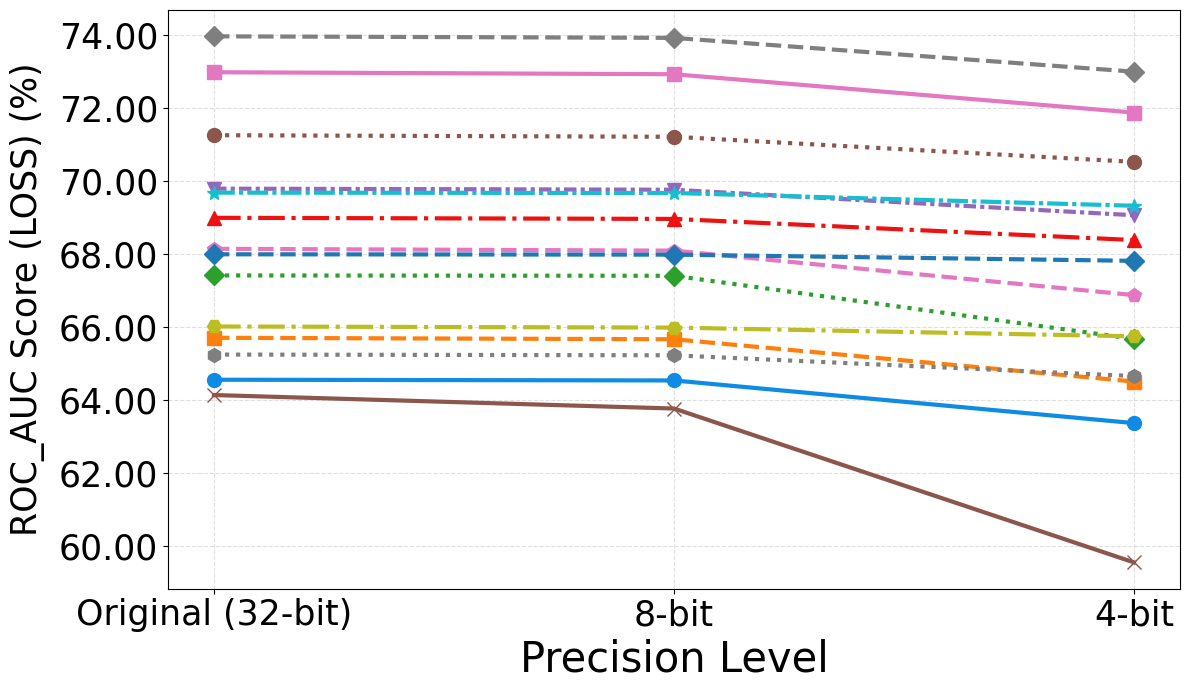

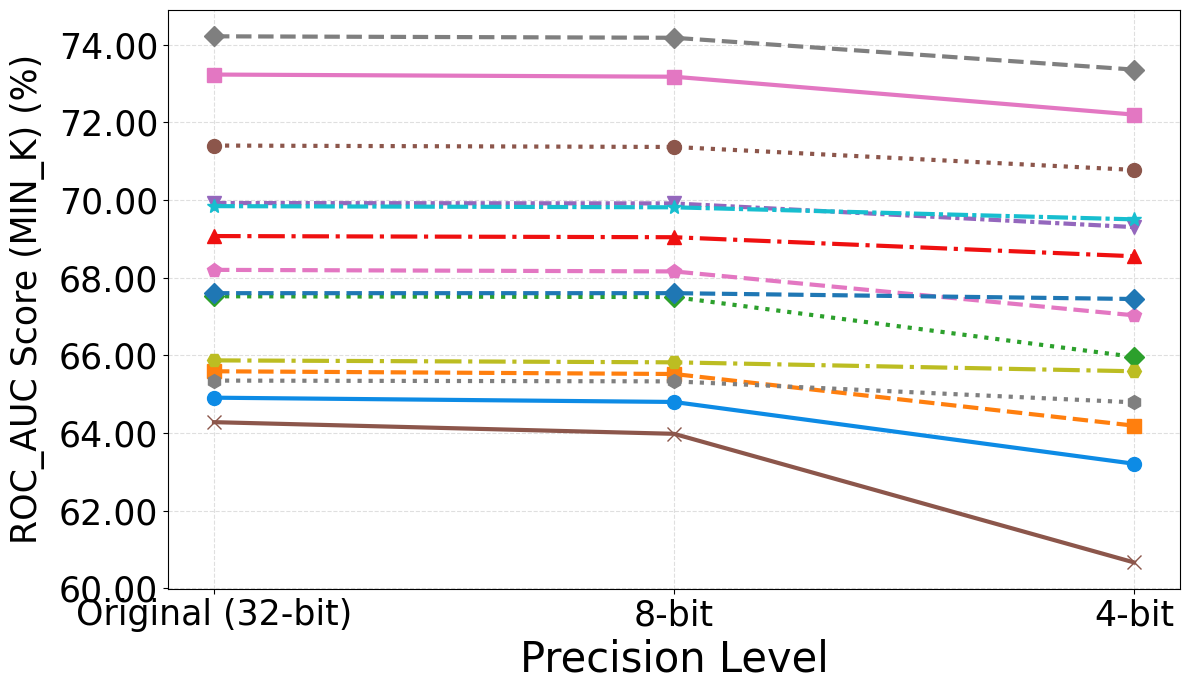

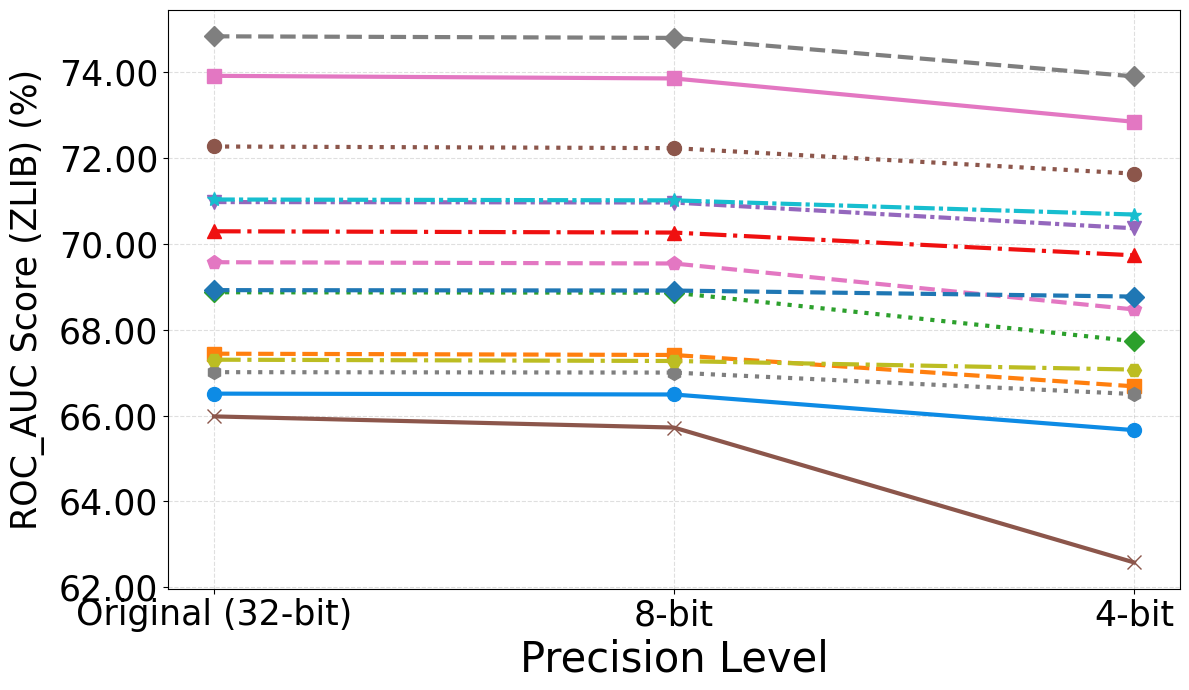

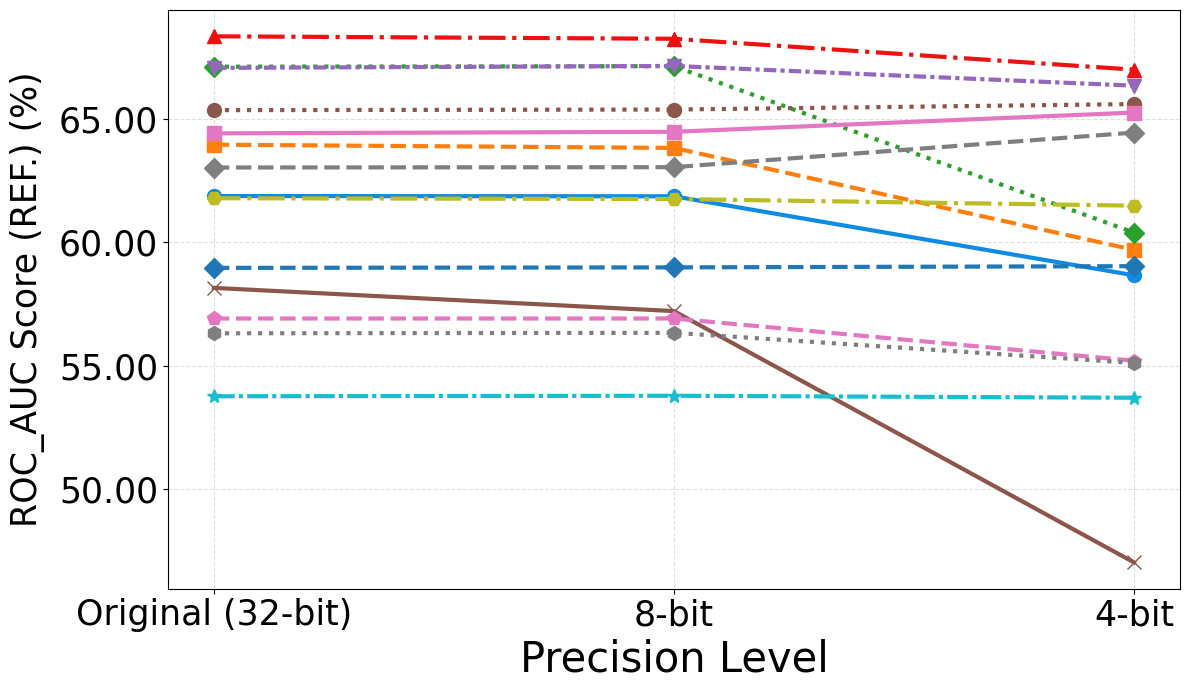

In [10]:
df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", "ROC_AUC"])
graph_roc_auc(df, score_col="ROC_AUC", miaName="LOSS", fileName="RQ-4.2.1")

df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", "ROC_AUC.1"])
df = df.rename(columns={"ROC_AUC.1": "ROC_AUC"})
graph_roc_auc(df, score_col="ROC_AUC", miaName="MIN_K", fileName="RQ-4.2.2")

df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", "ROC_AUC.2"])
df = df.rename(columns={"ROC_AUC.2": "ROC_AUC"})
graph_roc_auc(df, score_col="ROC_AUC", miaName="ZLIB", fileName="RQ-4.2.3")

df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", "ROC_AUC.3"])
df = df.rename(columns={"ROC_AUC.3": "ROC_AUC"})
graph_roc_auc(df, score_col="ROC_AUC", miaName="REF.", fileName="RQ-4.2.4")


# metric = "PR_AUC"

# df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", metric])
# graph_roc_auc(df, score_col=metric, miaName="LOSS", fileName="RQ-4.2.5")

# df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", "PR_AUC.1"])
# df = df.rename(columns={"PR_AUC.1": metric})
# graph_roc_auc(df, score_col=metric, miaName="MIN_K", fileName="RQ-4.2.6")

# df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", "PR_AUC.2"])
# df = df.rename(columns={"PR_AUC.2": metric})
# graph_roc_auc(df, score_col=metric, miaName="ZLIB", fileName="RQ-4.2.7")

# df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", "PR_AUC.3"])
# df = df.rename(columns={"PR_AUC.3": metric})
# graph_roc_auc(df, score_col=metric, miaName="REF.", fileName="RQ-4.2.8")

## RQ-2: Correlation between task performance and MIA

In [11]:
df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2)
df

,Model,Compression,Size (MB),BLEU,ROC_AUC,PR_AUC,ROC_AUC.1,PR_AUC.1,ROC_AUC.2,PR_AUC.2,ROC_AUC.3,PR_AUC.3
0,pythia-70M,Original,281.731842,42.000000,64.5500,60.870000,64.9100,61.320000,66.5100,62.860000,61.8700,56.280000
1,pythia-70M,8-bit,122.126906,41.390000,64.5300,60.860000,64.8000,61.200000,66.4900,62.870000,61.8600,56.320000
2,pythia-70M,4-bit,113.771074,39.210000,63.3600,60.440000,63.2100,60.400000,65.6600,62.540000,58.6600,54.290000
3,pythia-160M,Original,649.341186,42.490000,65.7000,61.640000,65.5900,61.570000,67.4400,63.550000,63.9500,58.170000
4,pythia-160M,8-bit,240.116642,42.310000,65.6600,61.570000,65.5200,61.460000,67.4100,63.500000,63.8200,58.100000
5,pythia-160M,4-bit,202.650482,40.600000,64.5000,61.120000,64.1900,60.900000,66.6800,63.270000,59.6900,55.090000
6,pythia-410M,Original,1621.430000,43.510000,67.4100,62.690000,67.5200,62.660000,68.8700,64.420000,67.1100,61.240000
7,pythia-410M,8-bit,509.700000,43.610000,67.4000,62.690000,67.5000,62.670000,68.8600,64.400000,67.1300,61.230000
8,pythia-410M,4-bit,376.750000,42.410000,65.6700,61.910000,65.9600,61.920000,67.7300,63.880000,60.3900,55.770000
9,pythia-1B,Original,4047.192000,44.180000,68.9900,63.860000,69.0700,63.930000,70.2900,65.540000,68.3400,63.680000


In [12]:
def generate_graphs(taskPerformance, MIA_attack, MIA_score, i):
    # Define styles
    model_order = ['pythia-70M', 'pythia-160M', 'pythia-410M', 'pythia-1B', 'pythia-1.4B', 'pythia-2.8B', 'pythia-6.9B', 'pythia-12B', 
                   'gptneo-125M', 'gptneo-1.3B', 'codegen-350M-nl', 'codegen-2B-nl', 
                   'codegen-350M-multi', 'codegen-2B-multi']
    short_names = {
        'pythia-70M': 'P-70M',
        'pythia-160M': 'P-160M',
        'pythia-410M': 'P-410M',
        'pythia-1B': 'P-1B',
        'pythia-1.4B': 'P-1.4B',
        'pythia-2.8B': 'P-2.8B',
        'pythia-6.9B': 'P-6.9B',
        'pythia-12B': 'P-12B',
        'gptneo-125M': 'GPT-125M',
        'gptneo-1.3B': 'GPT-1.3B',
        'codegen-350M-nl': 'CG-350M-NL',
        'codegen-2B-nl': 'CG-2B-NL',
        'codegen-350M-multi': 'CG-350M-Multi',
        'codegen-2B-multi': 'CG-2B-Multi'   
    }

    # Color scheme and patterns for models
    model_styles = {
        'pythia-70M': {'color': "#0d8be5", 'pattern': '////'},
        'pythia-160M': {'color': "#ff7f0e", 'pattern': '....'},
        'pythia-410M': {'color': "#2ca02c", 'pattern': 'xxxx'},
        'pythia-1B': {'color': "#ef1010", 'pattern': '++++'},
        'pythia-1.4B': {'color': "#9467bd", 'pattern': '----'},
        'pythia-2.8B': {'color': "#8c564b", 'pattern': '////'},
        'pythia-6.9B': {'color': "#e377c2", 'pattern': '....'},
        'pythia-12B': {'color': "#7f7f7f", 'pattern': 'xxxx'},
        'gptneo-125M': {'color': "#8c564b", 'pattern': '////'},
        'gptneo-1.3B': {'color': "#e377c2", 'pattern': '....'},
        'codegen-350M-nl': {'color': "#7f7f7f", 'pattern': 'xxxx'},
        'codegen-2B-nl': {'color': "#17becf", 'pattern': '++++'},
        'codegen-350M-multi': {'color': "#bcbd22", 'pattern': '----'},
        'codegen-2B-multi': {'color': "#1f77b4", 'pattern': '++++'} 
    }
    
    # Marker styles by compression type
    compression_markers = {
        'Original': {'marker': 'o', 'size': 120},
        '8-bit': {'marker': 's', 'size': 100},
        '4-bit': {'marker': '^', 'size': 100}
    }
    
    compression_order = ['Original', '8-bit', '4-bit']
    
    # Create single figure
    plt.figure(figsize=(14, 8))
    ax = plt.gca()
    
    # Plot all models with their compression types
    for compression in compression_order:
        for model in model_order:
            subset = df[(df['Model'] == model) & (df['Compression'] == compression)]
            if not subset.empty:
                ax.scatter(
                    subset[taskPerformance], subset[MIA_score],
                    c=model_styles[model]['color'],
                    marker=compression_markers[compression]['marker'],
                    s=compression_markers[compression]['size'],
                    alpha=0.8,
                    edgecolors='k',
                    linewidths=1.5,
                    hatch=model_styles[model]['pattern'],
                    label=f"{short_names[model]} {compression}"
                )
    
    # Regression line for all data
    sns.regplot(
        x=taskPerformance, y=MIA_score, data=df,
        scatter=False, ci=95,
        ax=ax,
        line_kws={
            'color': 'black', 
            'alpha': 0.4, 
            'linestyle': '--',
            'linewidth': 2.5
        }
    )
    
    # Overall correlation
    corr = df[taskPerformance].corr(df[MIA_score])
    ax.annotate(
        f'r = {corr:.3f}', 
        xy=(0.65, 0.3), 
        xycoords='axes fraction',
        fontsize=25,
        bbox=dict(boxstyle='round', alpha=0.3, edgecolor='gray')
    )
    
    # ax.set_title('All Models and Compression Types', fontsize=16)
    ax.set_xlabel('CodeBLEU Score (%)', fontsize=20)
    ax.set_ylabel(f'{MIA_score.split(".")[0]} Score ({MIA_attack}) (%)', fontsize=20)
    ax.grid(True, linestyle=':', alpha=0.3)
    
    # Format ticks
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))
    ax.tick_params(axis='both', labelsize=12)
    
    # Create legend elements
    model_legend_elements = [
        plt.Rectangle((0,0), 1, 1, 
                      fc=model_styles[model]['color'],
                      hatch=model_styles[model]['pattern'],
                      edgecolor='k',
                      label=short_names[model])
        for model in model_order
    ]
    
    compression_legend_elements = [
        Line2D([0], [0], 
               marker=compression_markers[comp]['marker'], 
               color='w',
               markerfacecolor='gray',
               markersize=10,
               markeredgecolor='k',
               label=comp)
        for comp in compression_order
    ]
    
    # Create and position legends
    legend1 = ax.legend(handles=model_legend_elements,
                    title='Models (P=Pythia)',
                    loc='upper left',
                    bbox_to_anchor=(0, 0.983),
                    fontsize=14,
                    ncol=4,
                    title_fontsize=15)
    
    ax.add_artist(legend1)
    
    ax.legend(handles=compression_legend_elements,
             title='Model Size',
             loc='upper right',
             bbox_to_anchor=(0.425, 0.78),
             fontsize=14,
             ncol=3,
             title_fontsize=14)
    ax.xaxis.set_tick_params(rotation=0, labelsize=18)
    ax.yaxis.set_tick_params(labelsize=18)
    # Adjust layout and save
    plt.tight_layout(rect=[0, 0, 0.85, 1])  # Make space for legends
    plt.savefig(f'./output/RQ4.3.{i}.pdf', dpi=350, bbox_inches='tight')
    plt.show()
    plt.close()

# Call the function
# generate_graphs("BLEU", "ZLIB", "ROC_AUC", 3)

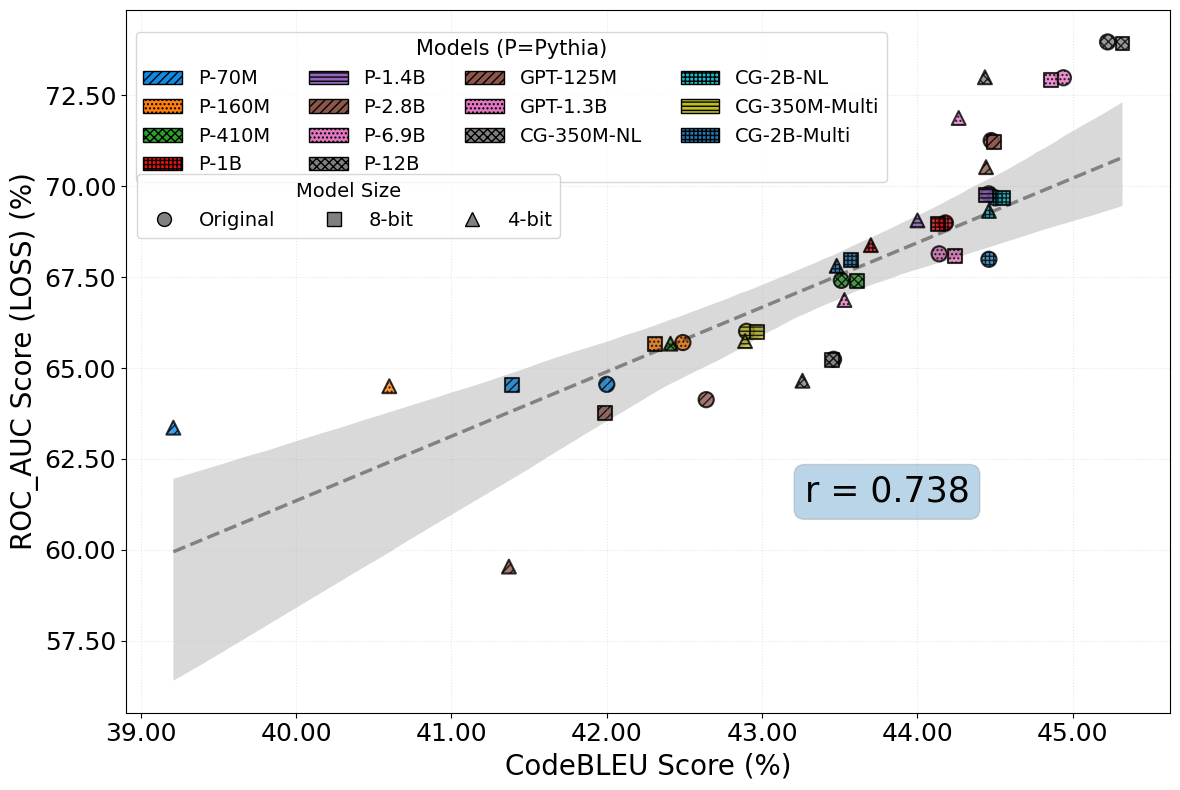

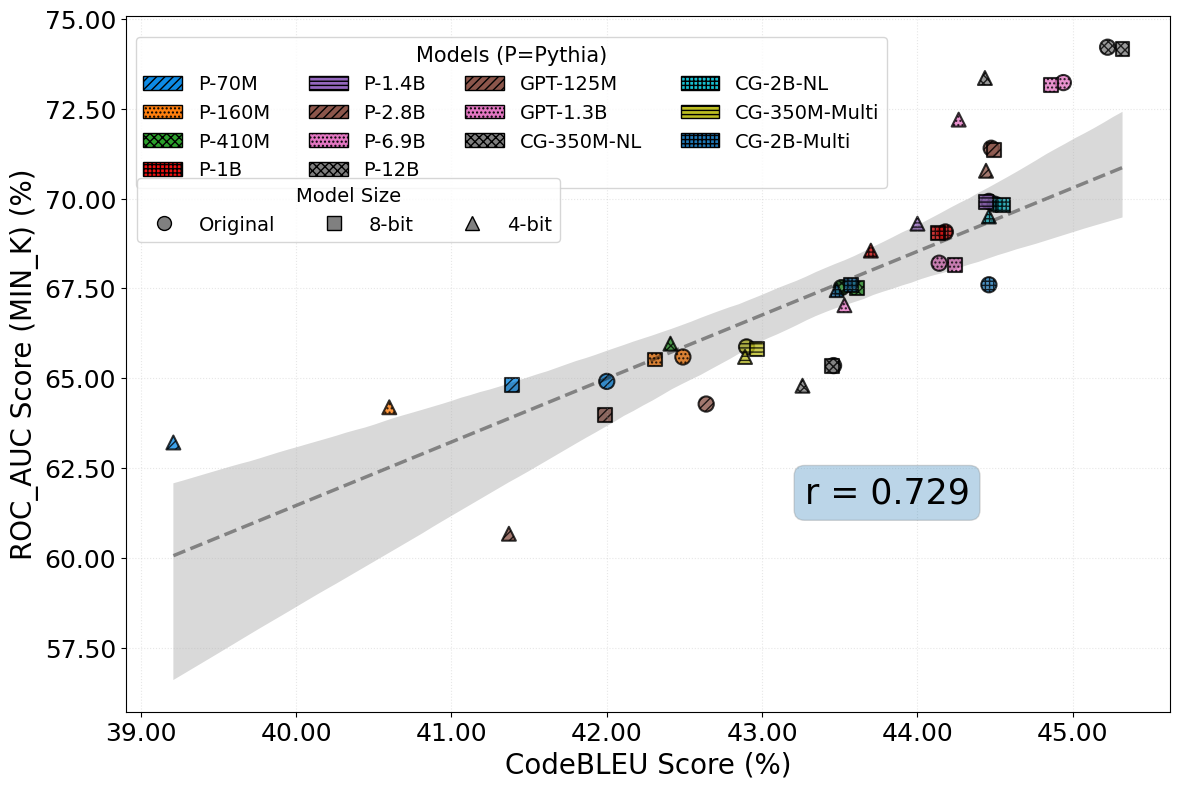

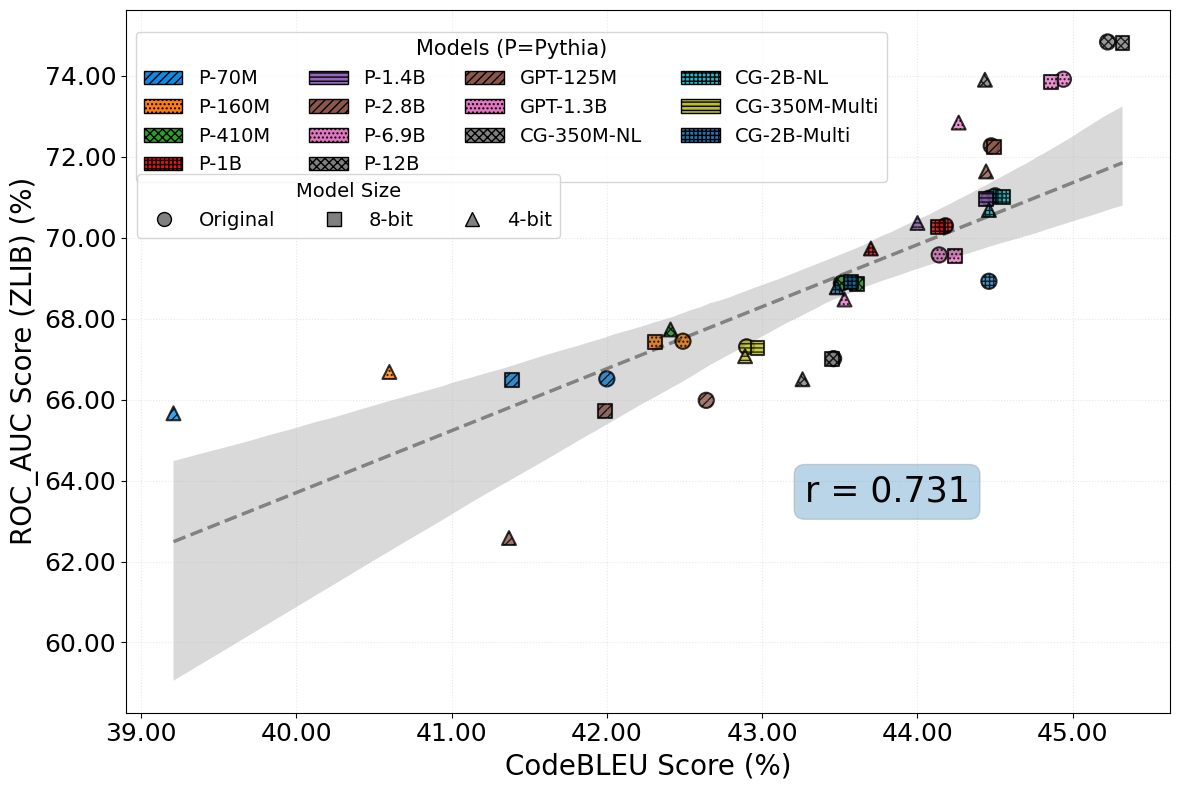

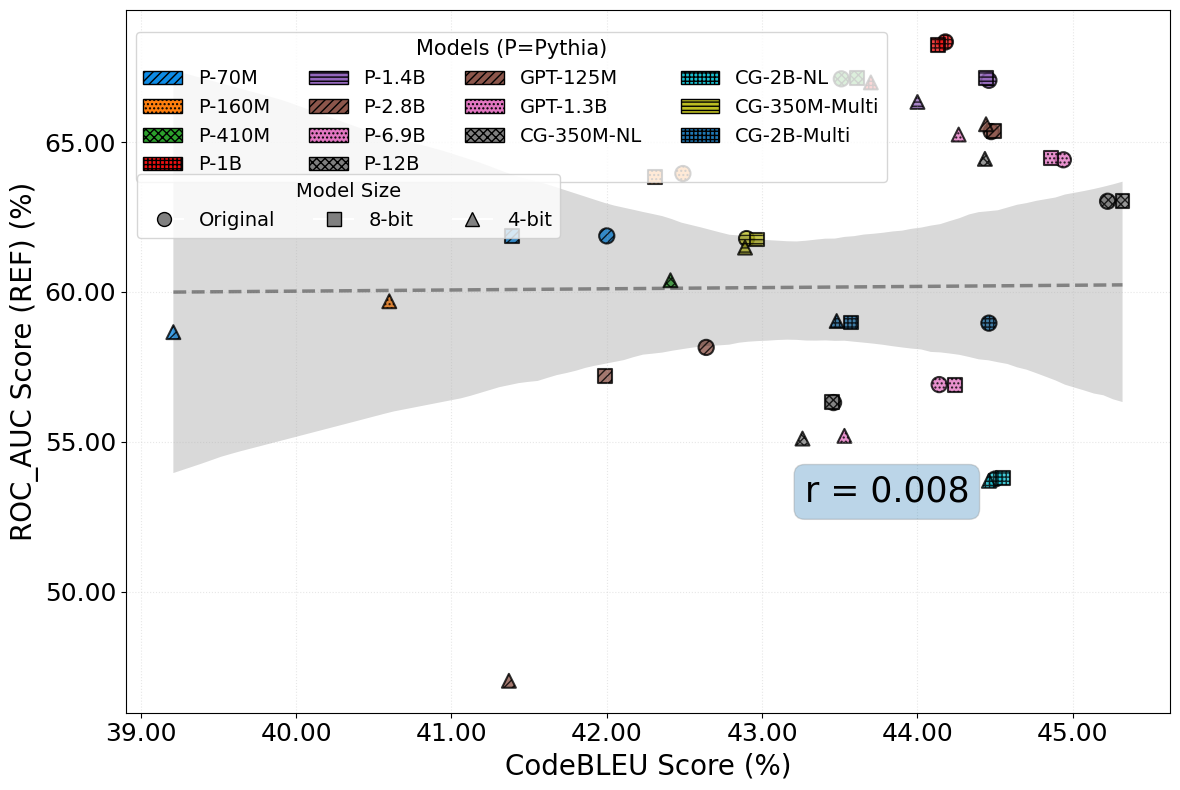

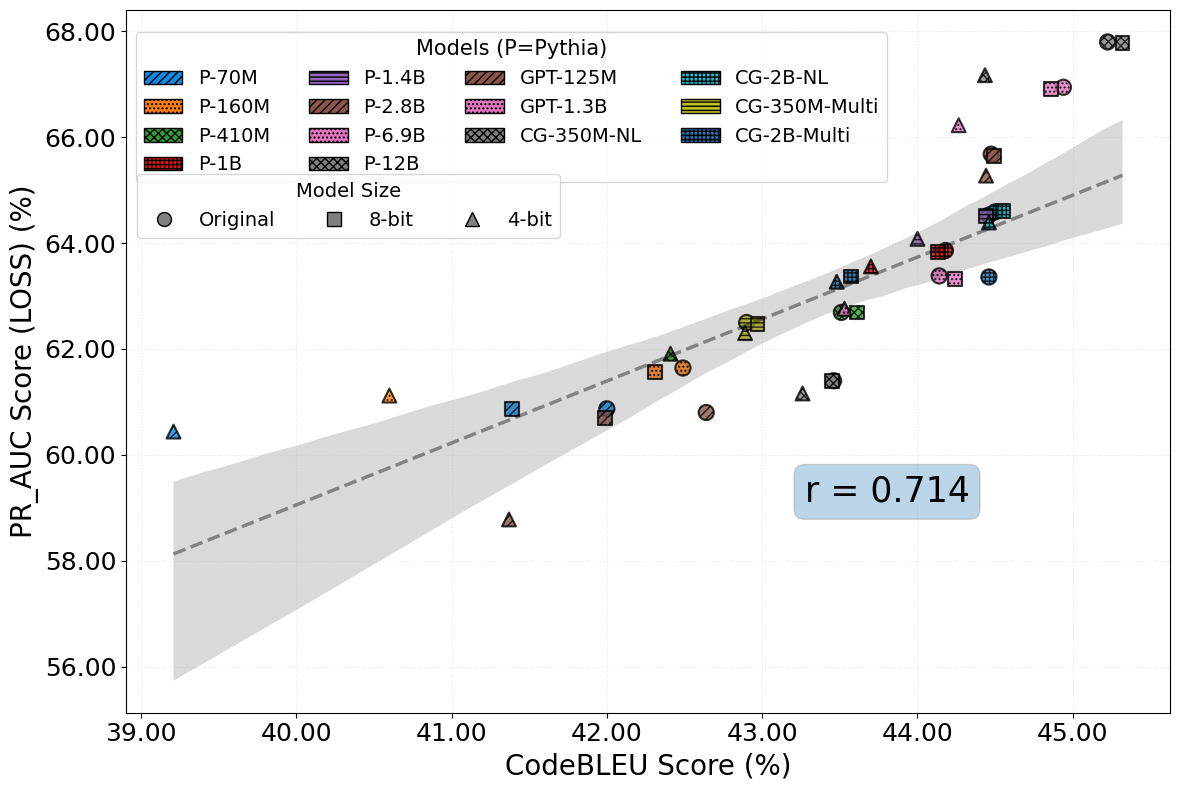

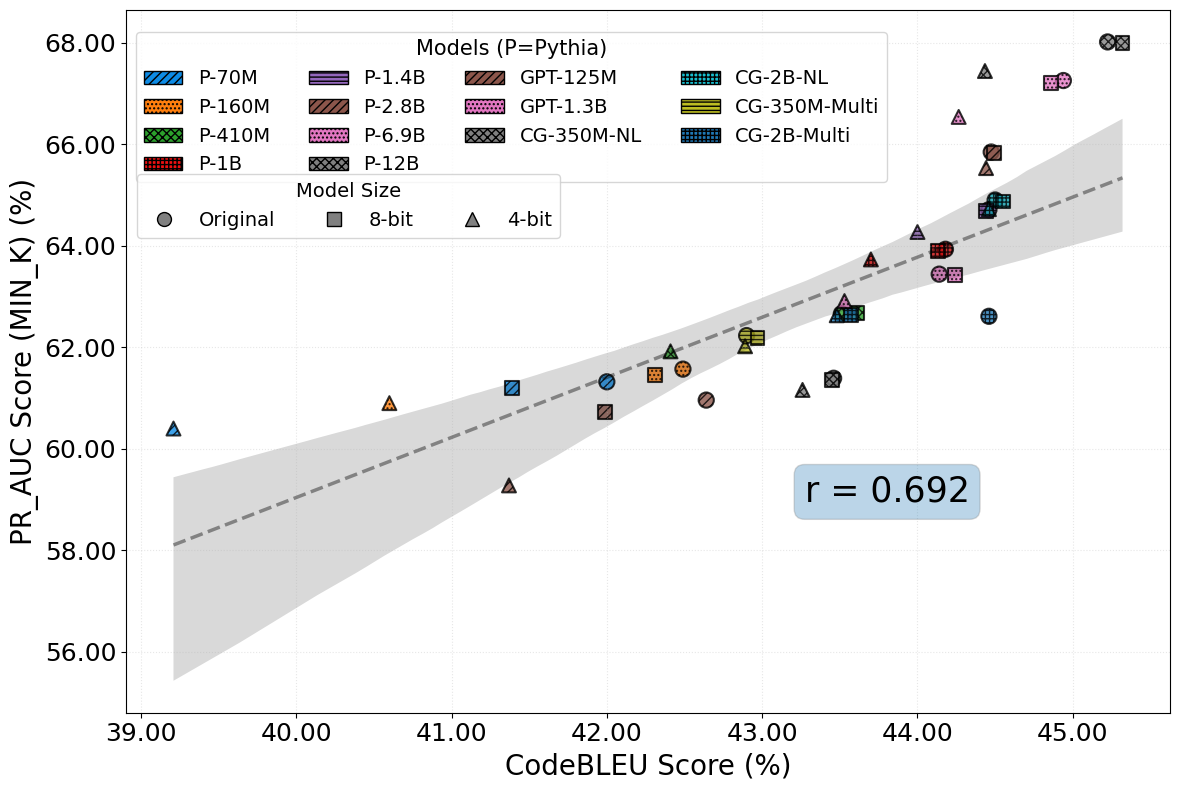

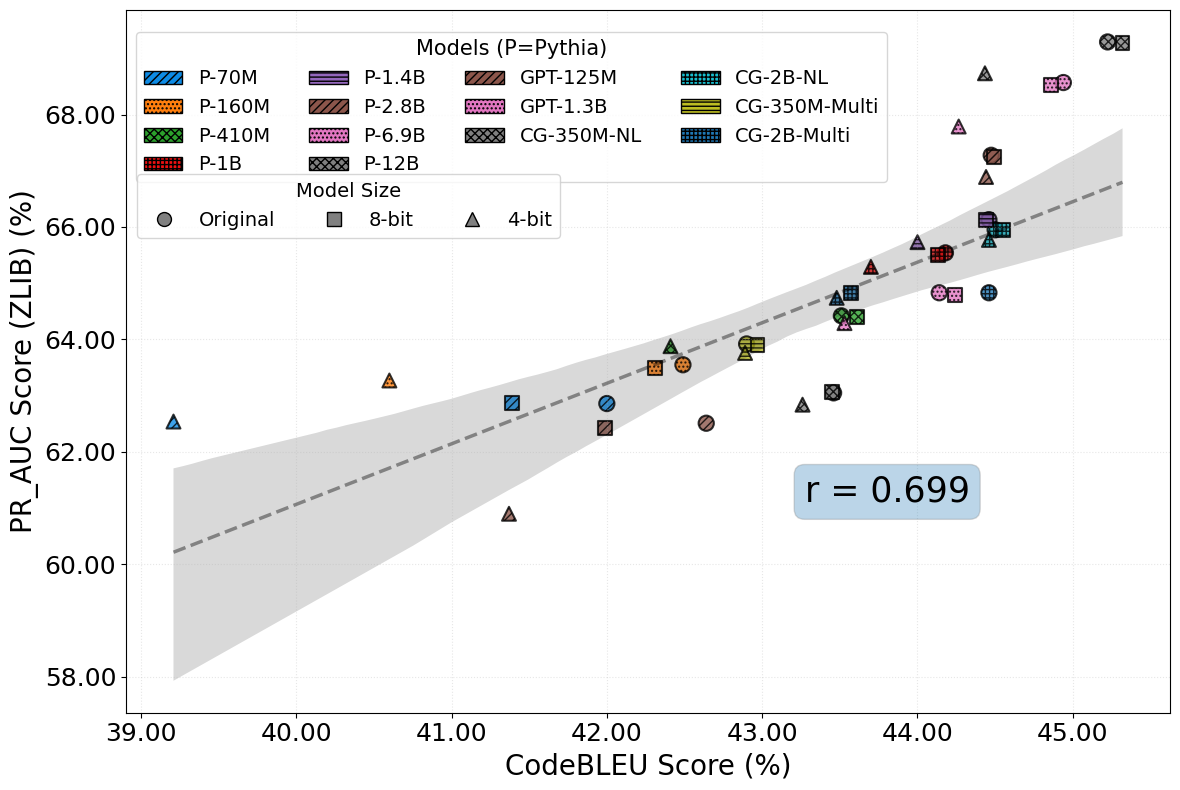

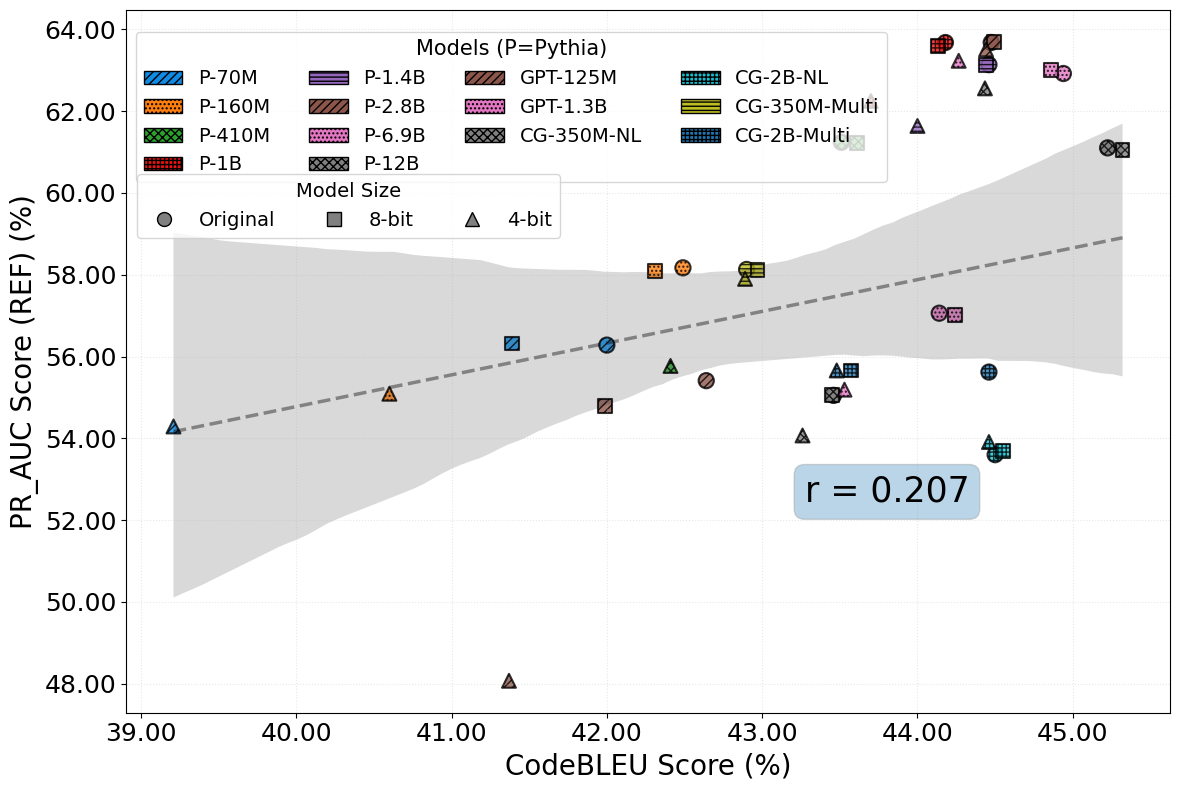

In [13]:
taskPerformance = "BLEU"
MIA_attacks = ["LOSS", "MIN_K", "ZLIB", "REF"]
MIA_scores = ["ROC_AUC", "ROC_AUC.1", "ROC_AUC.2", "ROC_AUC.3"]
for i, (MIA_attack, MIA_score) in enumerate(zip(MIA_attacks, MIA_scores), start=1):
    generate_graphs(taskPerformance, MIA_attack, MIA_score, i)


MIA_scores = ["PR_AUC", "PR_AUC.1", "PR_AUC.2", "PR_AUC.3"]
for i, (MIA_attack, MIA_score) in enumerate(zip(MIA_attacks, MIA_scores), start=5):
    generate_graphs(taskPerformance, MIA_attack, MIA_score, i)